<a href="https://colab.research.google.com/github/Yash-Poddar-12/YashPoddar-EDA-Project/blob/main/YashPoddar_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA) - Phase 1
* **Name:** Yash Poddar
* **Registration Number:** 23BDS0195
* **Institution:** Vellore Institute of Technology
* **Dataset:** Bank Marketing Dataset

In [48]:
# Importing the required libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [49]:
# Set the visual style for the plots to make them look clean
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

In [50]:
# 1. Loading the dataset
# Load the dataset directly from the provided URL
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/bank.csv"
df = pd.read_csv(url)
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [51]:
# 2. Applying basic statistical analysis
# Check the shape of our data, the data types, and get a statistical summary of the numerical columns
print(f"\nDataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")
df.info()

print("\nStatistical summary for numerical columns:")
display(df.describe())


Dataset Shape: 11162 rows and 17 columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB

Statistical summary for numerical columns:


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [52]:
# Calculate skewness and kurtosis to understand the distribution of numerical data
numeric_cols = df.select_dtypes(include=np.number).columns
skew_kurt = pd.DataFrame({
    'Skewness': df[numeric_cols].skew(),
    'Kurtosis': df[numeric_cols].kurt()
})
print("\nSkewness and Kurtosis:")
display(skew_kurt)


Skewness and Kurtosis:


,Skewness,Kurtosis
age,0.862780,0.621540
balance,8.224619,126.861303
day,0.111330,-1.061324
duration,2.143695,7.301282
campaign,5.545578,57.389771
pdays,2.449986,6.838359
previous,7.335298,106.197826


In [53]:
# 3. Handling missing data
# Check for standard missing values (NaNs) and placeholder "unknown" strings
print("\nStandard Missing Values:\n", df.isnull().sum())

categorical_cols = df.select_dtypes(include='object').columns

print("\n'Unknown' values per column:")
for col in categorical_cols:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        percentage = (unknown_count / len(df)) * 100
        print(f"{col}: {unknown_count} ({percentage:.2f}%)")


Standard Missing Values:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

'Unknown' values per column:
job: 70 (0.63%)
education: 497 (4.45%)
contact: 2346 (21.02%)
poutcome: 8326 (74.59%)


In [54]:
# 'poutcome' has ~74% unknowns, which is too high to impute. We will drop this column.
df.drop('poutcome', axis=1, inplace=True)
categorical_cols = categorical_cols.drop('poutcome')

# For 'contact', 'education', and 'job', replace 'unknown' with the mode (most frequent value)
for col in ['contact', 'education', 'job']:
    mode_value = df[col].mode()[0]
    df[col] = df[col].replace('unknown', mode_value)

print("\nMissing values handled. 'poutcome' dropped, and others imputed with mode.")


Missing values handled. 'poutcome' dropped, and others imputed with mode.


In [55]:
# 4. Data cleaning
# Check for any duplicate rows and standardize the text data
duplicates = df.duplicated().sum()
print(f"\nFound {duplicates} duplicate rows.")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("Text data cleaned and standardized.")


Found 0 duplicate rows.
Text data cleaned and standardized.


In [56]:
# 5. Data transformation
# Transform categorical Yes/No columns into binary numbers (1/0) [Encoding]
binary_columns = ['default', 'housing', 'loan', 'deposit']
for col in binary_columns:
    df[col + '_flag'] = df[col].map({'yes': 1, 'no': 0})

# Apply Log Transformation for skewed data (using np.sign() * np.log1p(abs()) for balance as it contains negatives)
df['balance_log'] = np.sign(df['balance']) * np.log1p(np.abs(df['balance']))
df['duration_log'] = np.log1p(df['duration'])

# Bin Age into categories for easier group-level analysis
bins = [17, 30, 40, 50, 60, 100]
labels = ['18-30', '31-40', '41-50', '51-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

print("\nData Transformation complete. Flags, log columns, and age groups created.")
display(df[['balance', 'balance_log', 'age', 'age_group', 'deposit', 'deposit_flag']].head())


Data Transformation complete. Flags, log columns, and age groups created.


,balance,balance_log,age,age_group,deposit,deposit_flag
0,2343,7.759614,59,51-60,yes,1
1,45,3.828641,56,51-60,yes,1
2,1270,7.147559,41,41-50,yes,1
3,2476,7.814803,55,51-60,yes,1
4,184,5.220356,54,51-60,yes,1


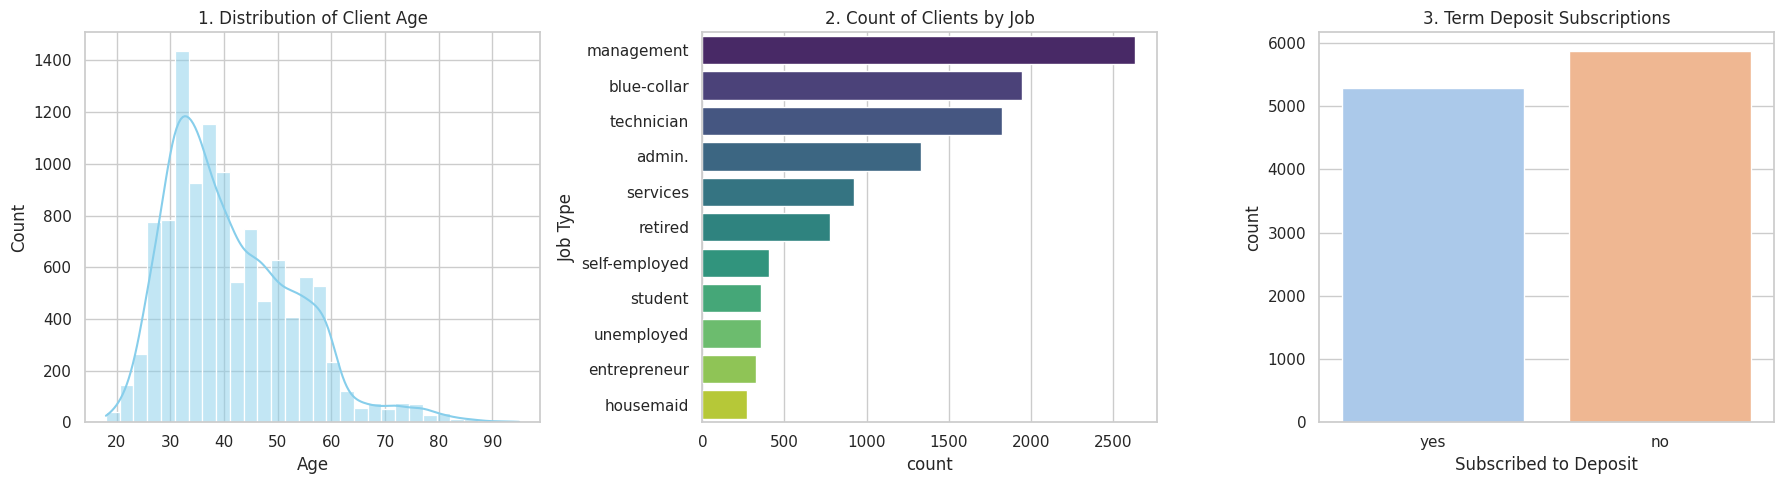

In [57]:
# 6. Univariate analysis

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('1. Distribution of Client Age')
plt.xlabel('Age')

plt.subplot(1, 3, 2)
order = df['job'].value_counts().index
sns.countplot(y='job', data=df, order=order, palette='viridis')
plt.title('2. Count of Clients by Job')
plt.ylabel('Job Type')

plt.subplot(1, 3, 3)
sns.countplot(x='deposit', data=df, palette='pastel')
plt.title('3. Term Deposit Subscriptions')
plt.xlabel('Subscribed to Deposit')

plt.tight_layout()
plt.show()

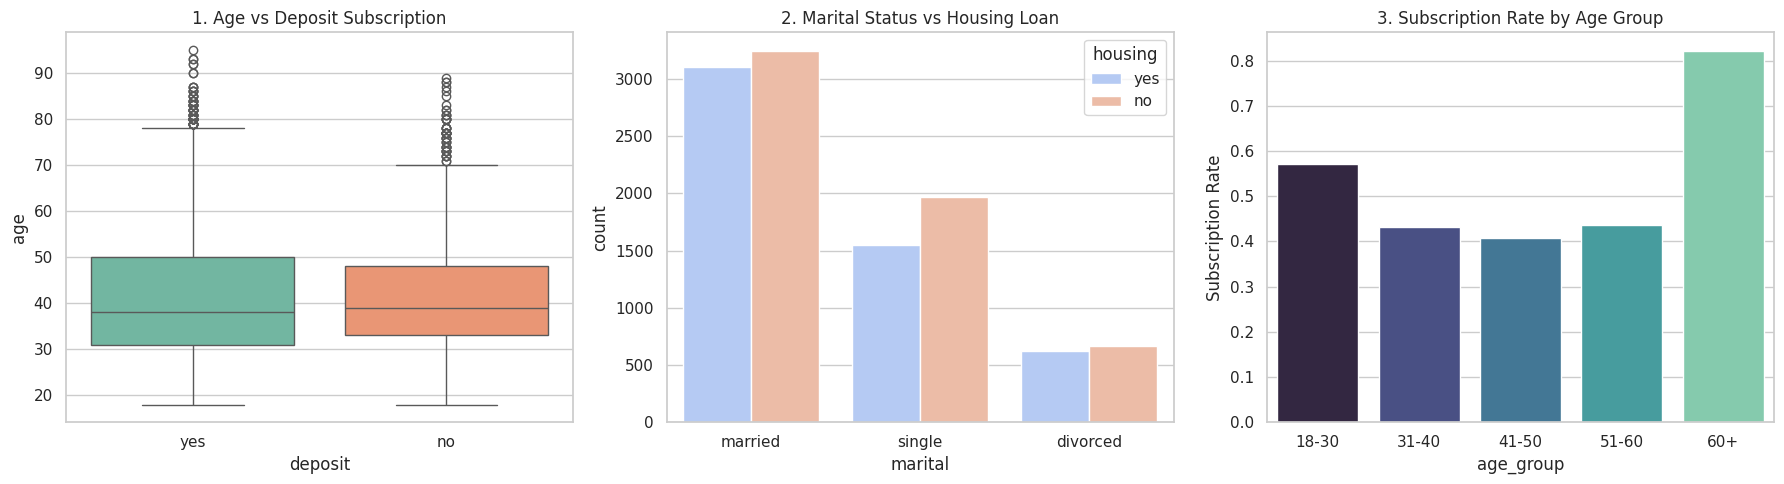

In [58]:
# 7. Bivariate analysis
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.boxplot(x='deposit', y='age', data=df, palette='Set2')
plt.title('1. Age vs Deposit Subscription')

plt.subplot(1, 3, 2)
sns.countplot(x='marital', hue='housing', data=df, palette='coolwarm')
plt.title('2. Marital Status vs Housing Loan')

plt.subplot(1, 3, 3)
age_deposit = df.groupby('age_group')['deposit_flag'].mean().reset_index()
sns.barplot(x='age_group', y='deposit_flag', data=age_deposit, palette='mako')
plt.title('3. Subscription Rate by Age Group')
plt.ylabel('Subscription Rate')

plt.tight_layout()
plt.show()

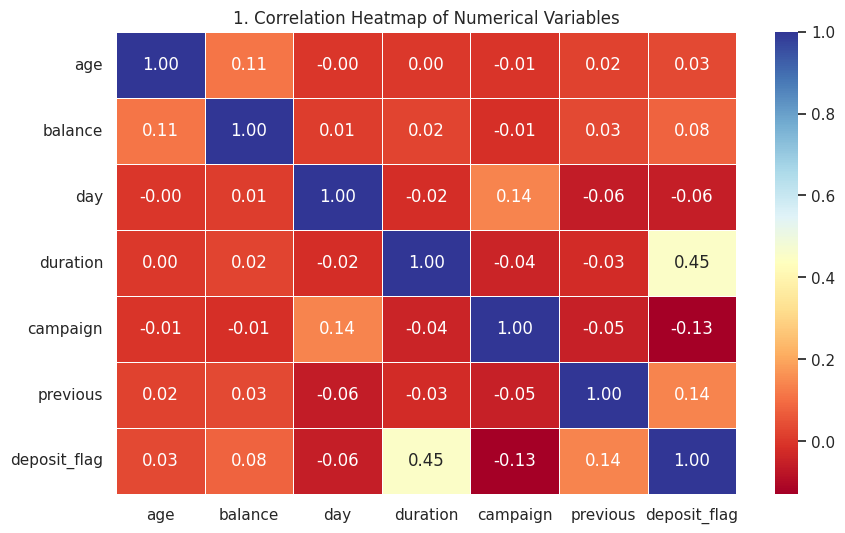

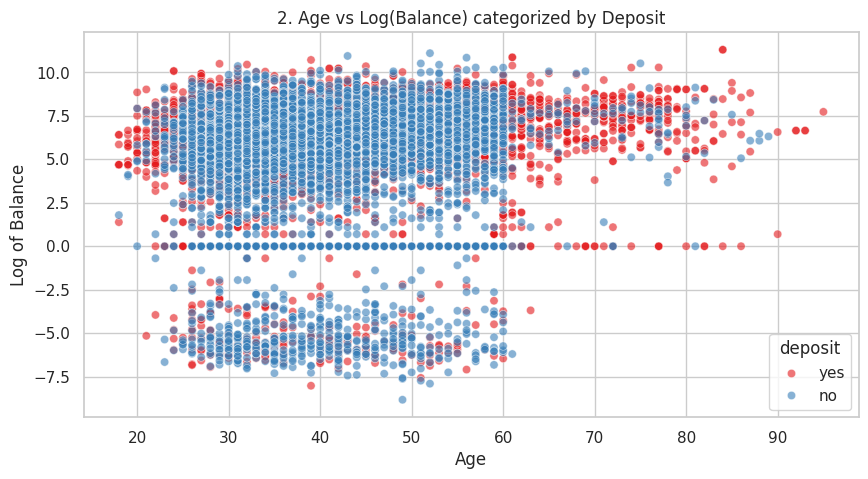

<Figure size 1200x800 with 0 Axes>

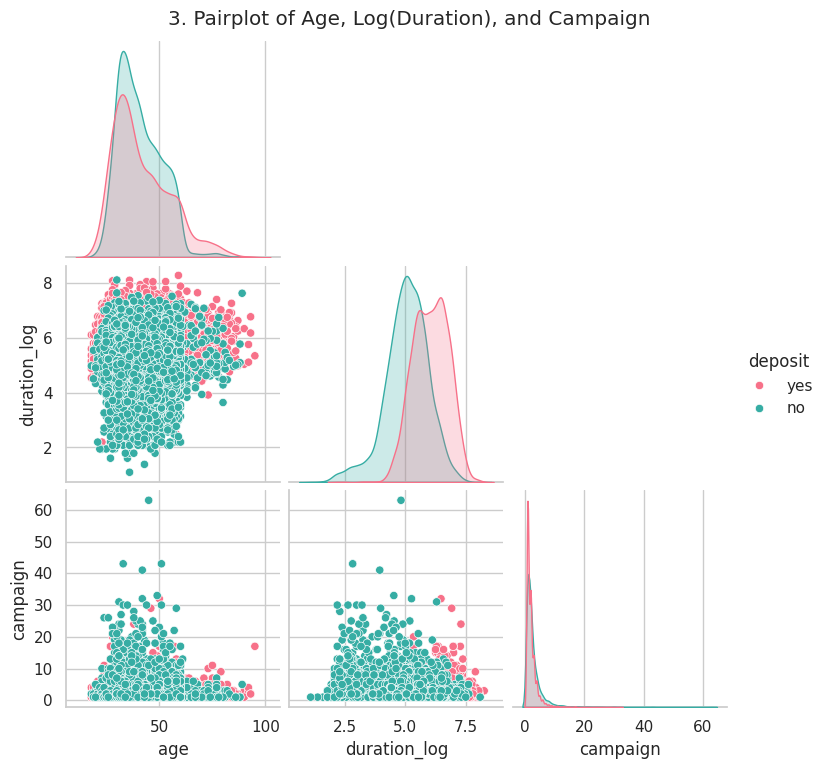

In [59]:
# 8. Multivariate analysis
plt.figure(figsize=(10, 6))
num_subset = ['age', 'balance', 'day', 'duration', 'campaign', 'previous', 'deposit_flag']
corr_matrix = df[num_subset].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu', fmt='.2f', linewidths=0.5)
plt.title('1. Correlation Heatmap of Numerical Variables')
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(x='age', y='balance_log', hue='deposit', data=df, alpha=0.6, palette='Set1')
plt.title('2. Age vs Log(Balance) categorized by Deposit')
plt.xlabel('Age')
plt.ylabel('Log of Balance')
plt.show()

plt.figure(figsize=(12, 8))
pairplot_vars = ['age', 'duration_log', 'campaign', 'deposit']
sns.pairplot(df[pairplot_vars], hue='deposit', palette='husl', corner=True)
plt.suptitle('3. Pairplot of Age, Log(Duration), and Campaign', y=1.02)
plt.show()